In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score

import matplotlib.colors as mcolors

In [2]:
base_artifacts = Path.cwd().resolve().parents[1] / 'CausalI2I_artifacts'
raw_results = pd.read_csv(base_artifacts / 'Datasets' / 'Simulation' / 'simulation_evaluated.csv')

In [3]:
new_names = {
    'ATE_OM': 'OM',
    'ATE_DR': 'DR',
    'ATE_STABILIZED': 'ATE (stabilized)',
    'cosine_similarity': 'Cosine',
    'correlation': 'Pearson',
    'diff_of_conditionals': 'DoC',
    'jacard_index': 'Jaccard',
    'sasrec_score': 'SASRec'
}
raw_results = raw_results.rename(columns=new_names)

raw_results['causal_link'] = (raw_results['causal_effect'] > 0).astype(int)

eps = 0.001
raw_results['STE'] = raw_results[['ATE', 'STD']].apply(lambda row: row['ATE'] / np.max([row['STD'], eps]), axis=1)
raw_results['ABLT/STD'] = raw_results[['ABLT', 'STD_ABLT']].apply(lambda row: row['ABLT'] / np.max([row['STD_ABLT'], eps]), axis=1)
raw_results['DR/STD'] = raw_results[['DR', 'STD_DR']].apply(lambda row: row['DR'] / np.max([row['STD_DR'], eps]), axis=1)
raw_results['STE (stabilized)'] = raw_results[['ATE (stabilized)', 'STD_STABILIZED']].apply(lambda row: row['ATE (stabilized)'] / np.max([row['STD_STABILIZED'], eps]), axis=1)

auxiliary = False
if auxiliary:
    baselines = ["ATE", "STE", "Pearson", "DoC", "SASRec", "OM", "ABLT", "ABLT/STD", "Cosine", "Jaccard", "DR", "DR/STD", "ATE (stabilized)", "STE (stabilized)"]
else:
    baselines = ["ATE", "STE", "Pearson", "DoC", "SASRec", "OM", "ABLT", "ABLT/STD"]

In [4]:
Ks = [10, 20, 50, 100, 200, 500, 1000]

vals2plot = {col: None for col in baselines}
for col in baselines:
    col_choises = raw_results.sort_values(by=col, ascending=False)['causal_link'].values
    vals2plot[col] = {K: np.sum(col_choises[:K]) for K in Ks}
total_positives = np.sum(raw_results['causal_link'].values)

summary = {}
for K in Ks:
    summary[('Precision@K (%)', f'K={K}')] = {
        col: 100 * vals2plot[col][K] / K
        for col in baselines}
for K in Ks:
    summary[('Recall@K (%)', f'K={K}')] = {
        col: 100 * vals2plot[col][K] / total_positives
        for col in baselines}
    
summary_df = pd.DataFrame(summary).map(lambda x: f'{x:.2f}')
summary_df

Precision@K (%)                                            \
                    K=10   K=20   K=50  K=100  K=200  K=500 K=1000   
ATE                 0.00  20.00  66.00  82.00  89.50  74.60  44.00   
STE                 0.00  35.00  68.00  82.00  90.50  75.00  43.40   
Pearson            10.00   5.00  62.00  77.00  78.00  55.00  36.10   
DoC                10.00   5.00  60.00  60.00  54.00  40.40  29.10   
SASRec              0.00   0.00   4.00   8.00   6.50   7.00   7.50   
OM                 60.00  40.00  34.00  35.00  26.50  17.80  14.00   
ABLT               10.00  45.00  50.00  47.00  39.00  21.40  13.60   
ABLT/STD            0.00  35.00  54.00  48.00  38.50  24.40  17.40   

         Recall@K (%)                                          
                 K=10  K=20  K=50  K=100  K=200  K=500 K=1000  
ATE              0.00  0.65  5.38  13.38  29.20  60.85  71.78  
STE              0.00  1.14  5.55  13.38  29.53  61.17  70.80  
Pearson          0.16  0.16  5.06  12.56  25.45  44.86  58.89  
DoC              0.16  0.16  4.89   9.79  17.62  32.95  47.47  
SASRec           0.00  0.00  0.33   1.31   2.12   5.71  12.23  
OM               0.98  1.31  2.77   5.71   8.65  14.52  22.84  
ABLT             0.16  1.47  4.08   7.67  12.72  17.46  22.19  
ABLT/STD         0.00  1.14  4.40   7.83  12.56  19.90  28.38

In [5]:
cmap = plt.get_cmap("tab10")
color_map = {}
for i, col in enumerate(baselines):
    base_color = cmap(i % 10)
    if i < 10:
        color_map[col] = base_color
    else:
        c = mcolors.to_rgb(base_color)
        color_map[col] = tuple(min(1, x * 1.4) for x in c)

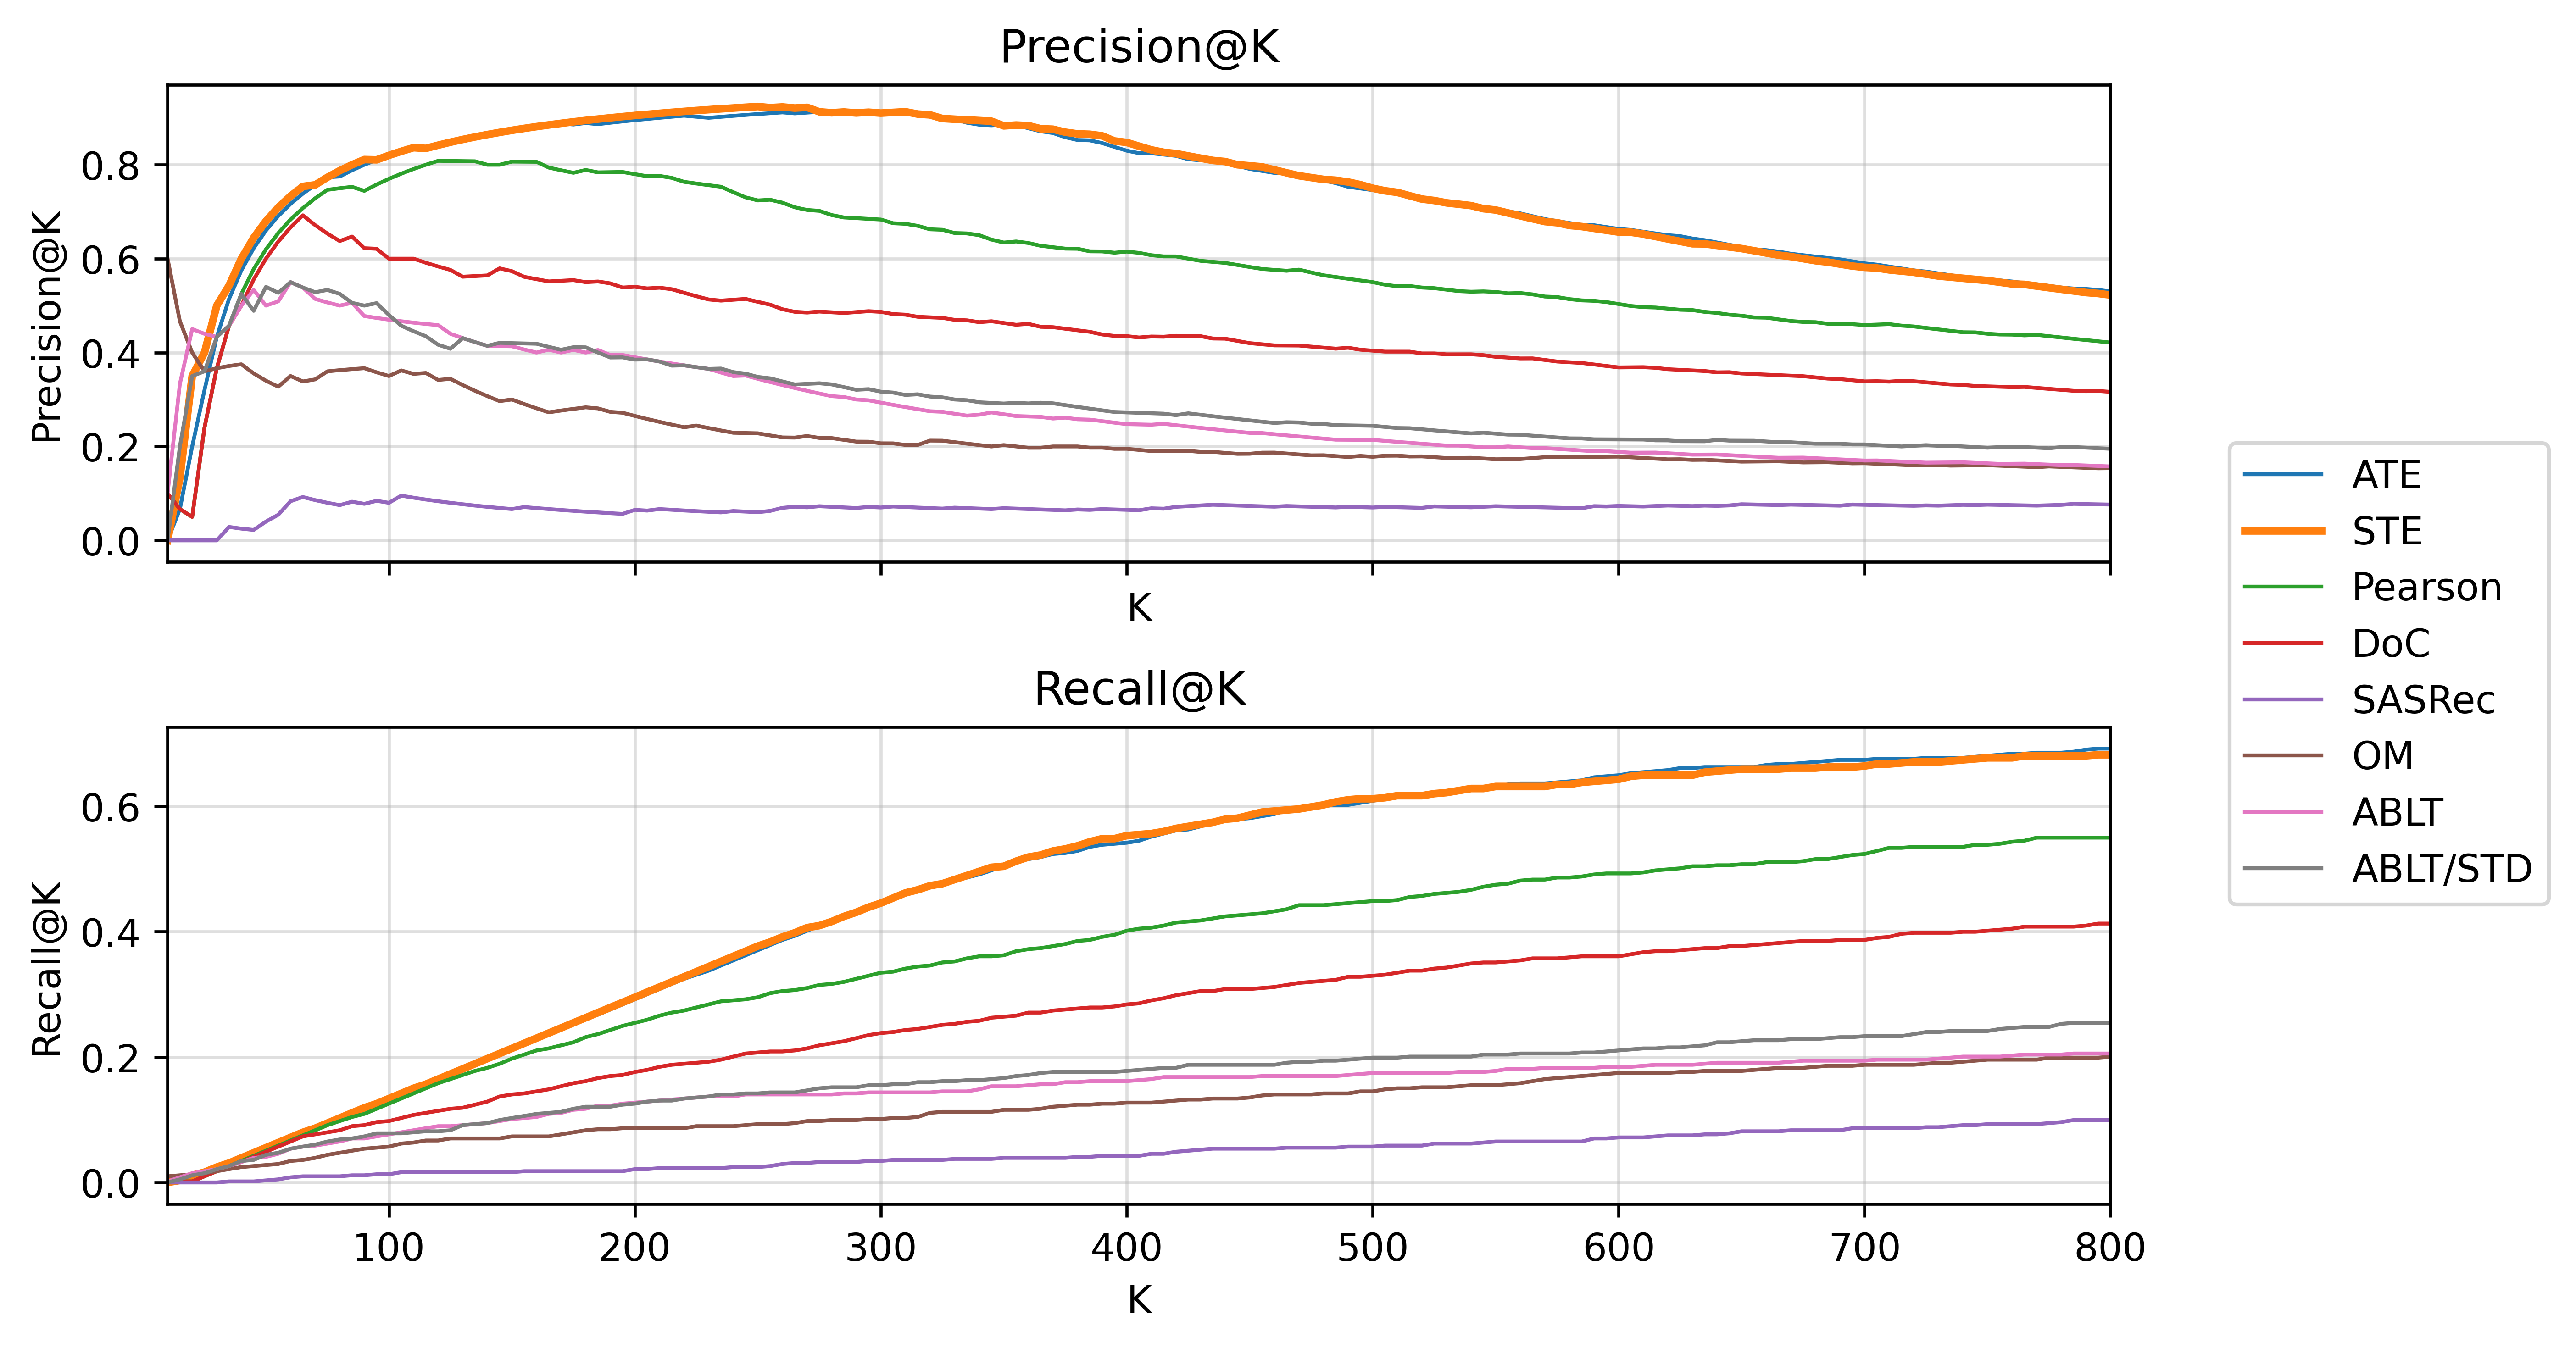

In [6]:
Ks = np.arange(10, 801, step=5)
total_positives = (raw_results['causal_link'] > 0).sum()

fig, axes = plt.subplots(2, 1, figsize=(8, 5), dpi=600, sharex=True)

# --- store curves and means ---
precision_curves = {}
recall_curves = {}
mean_precision = {}
mean_recall = {}

# ---- compute curves ----
for col in baselines:
    col_ser = raw_results.sort_values(by=col, ascending=False)['causal_link']

    precision_vals = np.array([col_ser[:K].sum() / K for K in Ks])
    recall_vals = np.array([col_ser[:K].sum() / total_positives for K in Ks])

    precision_curves[col] = precision_vals
    recall_curves[col] = recall_vals

    mean_precision[col] = precision_vals.mean()
    mean_recall[col] = recall_vals.mean()

# ---- plot Precision@K ----
for col in baselines:
    axes[0].plot(
        Ks,
        precision_curves[col],
        color=color_map[col],
        linewidth=2 if col == 'STE' else 1,
        label=col
    )

# ---- plot Recall@K ----
for col in baselines:
    axes[1].plot(
        Ks,
        recall_curves[col],
        color=color_map[col],
        linewidth=2 if col == 'STE' else 1,
        label=col
    )

# ---- Titles ----
axes[0].set_title("Precision@K")
axes[1].set_title("Recall@K")

# ---- Labels ----
axes[0].set_ylabel("Precision@K")
axes[1].set_ylabel("Recall@K")

# ---- Grid + limits ----
for ax in axes:
    ax.set_xlabel("K")
    ax.grid(alpha=0.4)
    ax.set_xlim([Ks[0], Ks[-1]])

# ---- Shared legend ----
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    bbox_to_anchor=(1.01, 0.5),
    loc="center left"
)

plt.tight_layout()
plt.savefig(
    base_artifacts / 'Figures' / 'simulation' / 'precision_recall_synthetic.jpeg', 
    bbox_inches='tight'
)
plt.show()


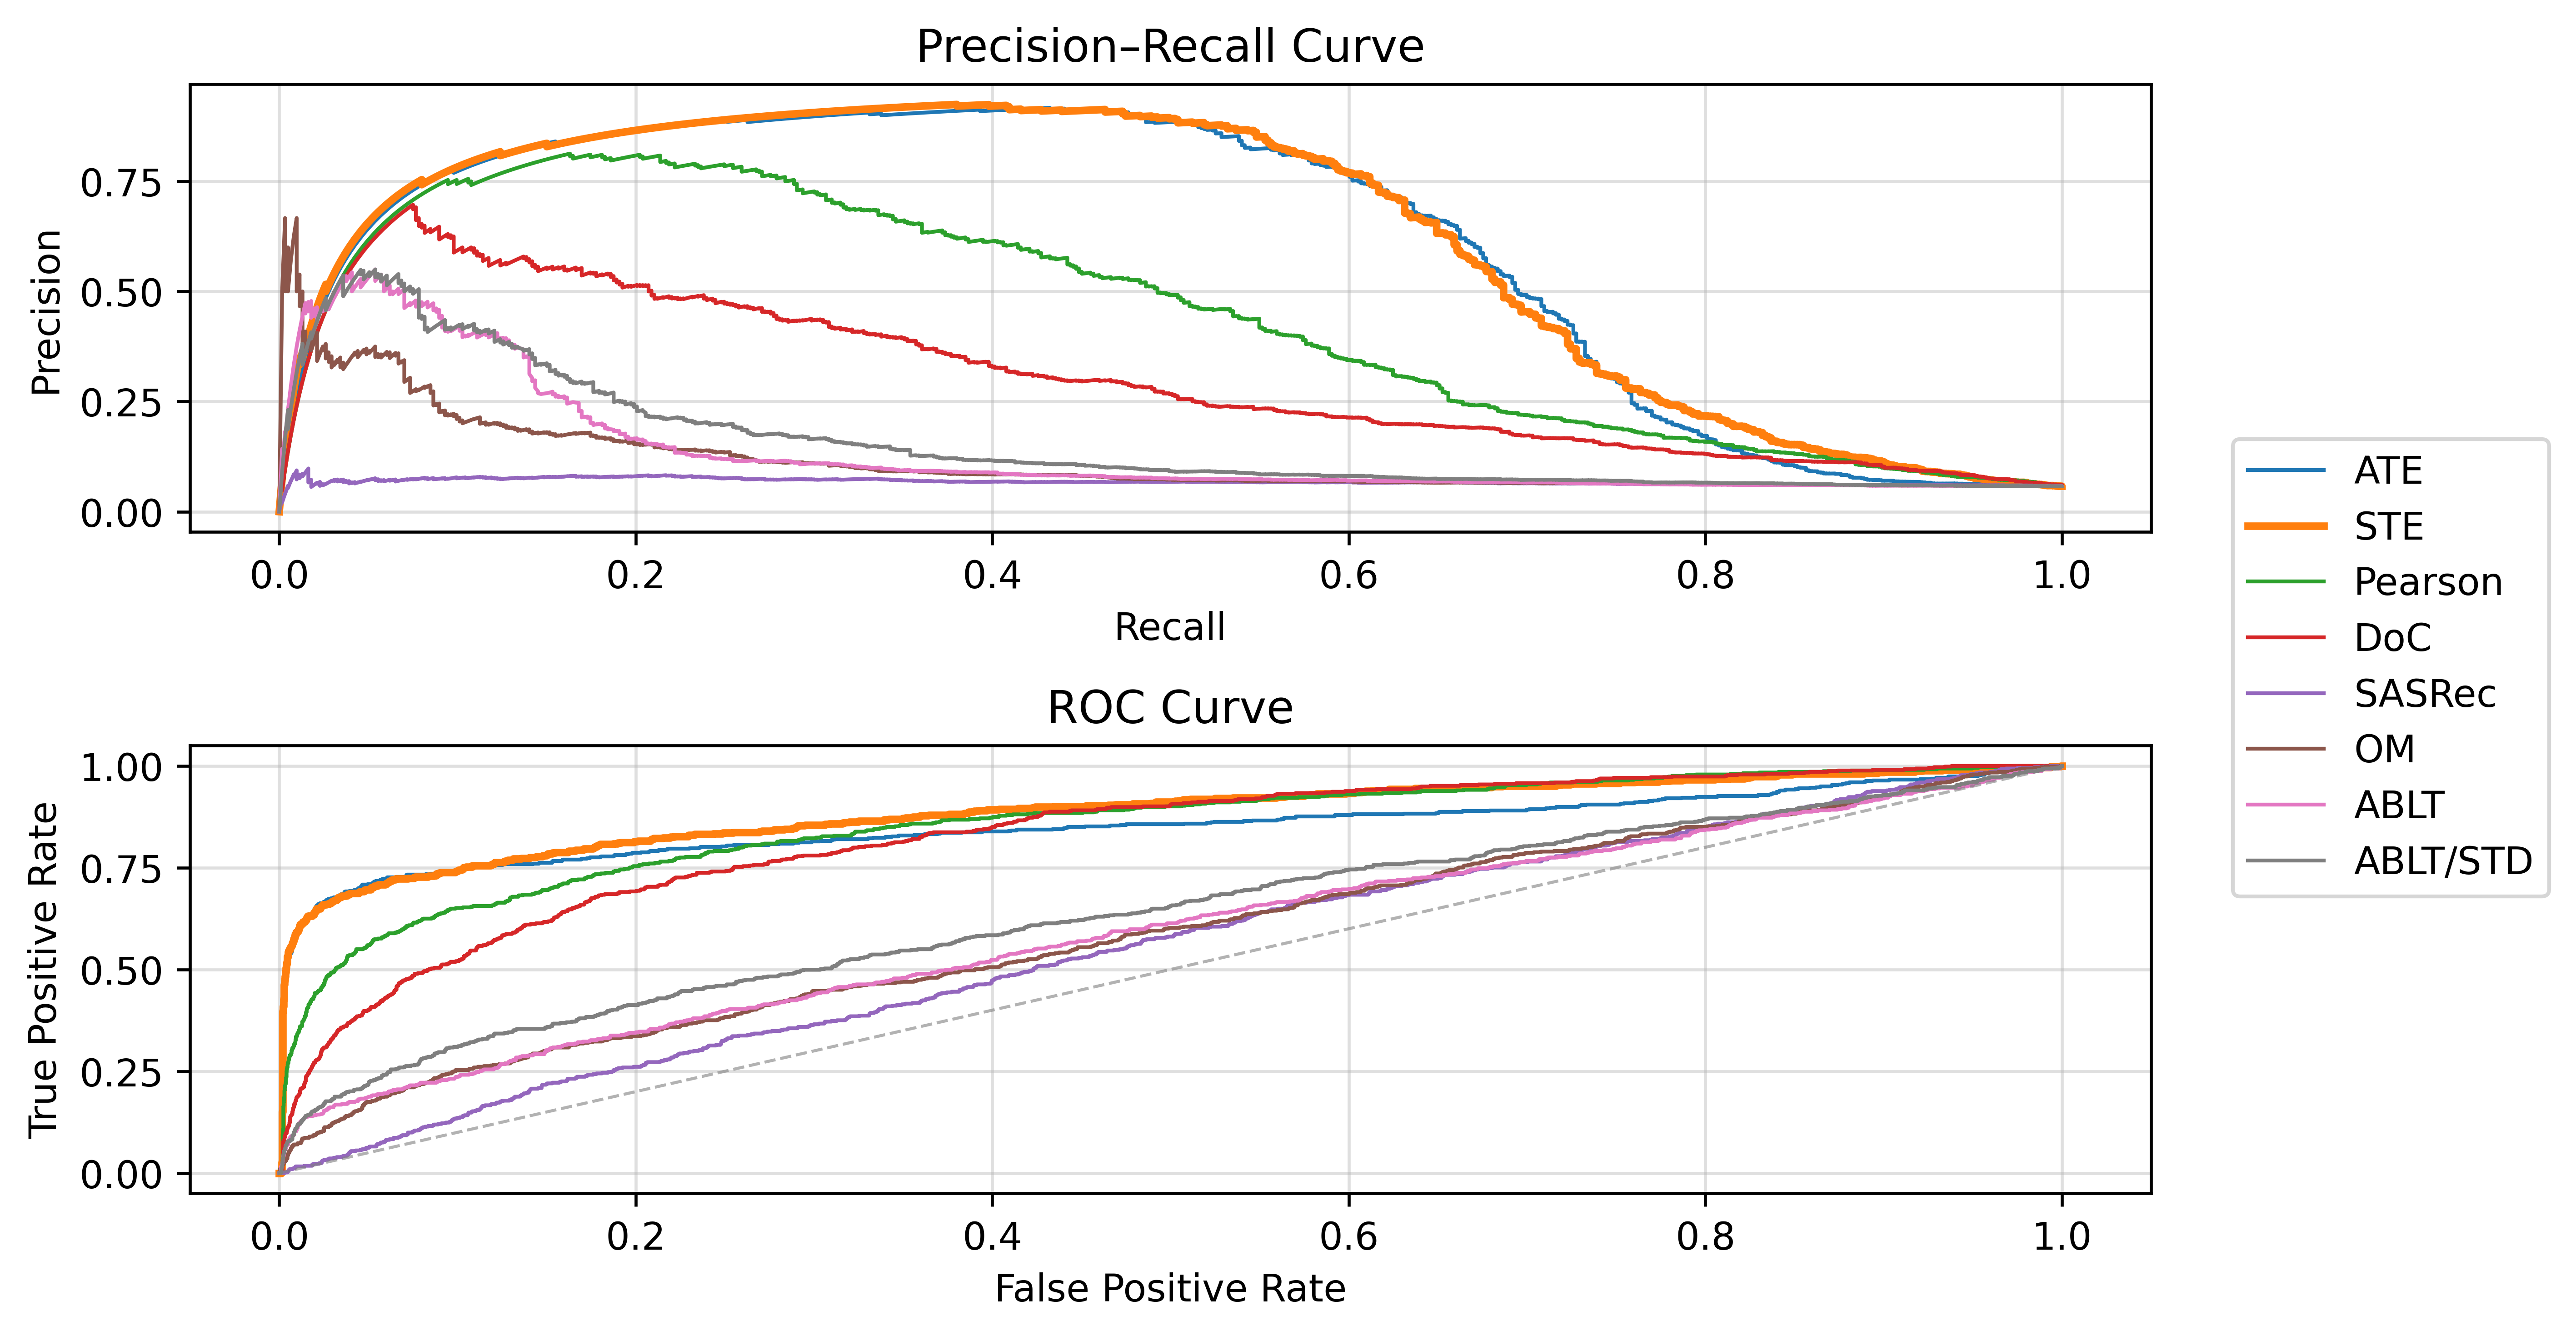

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), dpi=600, sharex=False)

y_true = raw_results['causal_link'].values

# --- store curves and scores ---
pr_curves = {}
roc_curves = {}
ap_scores = {}
auc_scores = {}

# ---- compute curves + scores ----
for col in baselines:
    y_score = raw_results[col].values

    precision, recall, _ = precision_recall_curve(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)

    pr_curves[col] = (recall[:-1], precision[:-1])
    roc_curves[col] = (fpr, tpr)

    ap_scores[col] = average_precision_score(y_true, y_score)
    auc_scores[col] = roc_auc_score(y_true, y_score)

# ---- plot Precision–Recall ----
for col in baselines:
    recall, precision = pr_curves[col]
    axes[0].plot(
        recall,
        precision,
        color=color_map[col],
        linewidth=2 if col == 'STE' else 1,
        label=col
    )

# ---- plot ROC ----
for col in baselines:
    fpr, tpr = roc_curves[col]
    axes[1].plot(
        fpr,
        tpr,
        color=color_map[col],
        linewidth=2 if col == 'STE' else 1,
        label=col
    )

# ---- Titles ----
axes[0].set_title("Precision–Recall Curve")
axes[1].set_title("ROC Curve")

# ---- Labels ----
axes[0].set_ylabel("Precision")
axes[0].set_xlabel("Recall")

axes[1].set_ylabel("True Positive Rate")
axes[1].set_xlabel("False Positive Rate")

# ---- Grid ----
for ax in axes:
    ax.grid(alpha=0.4)
axes[1].plot([0, 1], [0, 1], ls="--", lw=0.8, color="grey", alpha=0.6)

# ---- Shared legend ----
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    bbox_to_anchor=(1.01, 0.5),
    loc="center left"
)

plt.tight_layout()
plt.savefig(
    base_artifacts / 'Figures' / 'simulation' / 'pr_roc_synthetic.jpeg', 
    bbox_inches='tight'
)
plt.show()


In [8]:
ap_results = {}
auc_results = {}

summary = {}
y_true = raw_results['causal_link'].values
for col in baselines:
    y_score = raw_results[col].values
    ap = average_precision_score(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    auc_results[col] = auc
    summary[col] = {'AP': ap, 'AUC': auc}

summary_df = pd.DataFrame(summary).map(lambda x: f'{x:.3f}').T
summary_df


,AP,AUC
ATE,0.607,0.850
STE,0.617,0.885
Pearson,0.444,0.855
DoC,0.302,0.826
SASRec,0.068,0.557
OM,0.117,0.592
ABLT,0.139,0.594
ABLT/STD,0.158,0.636


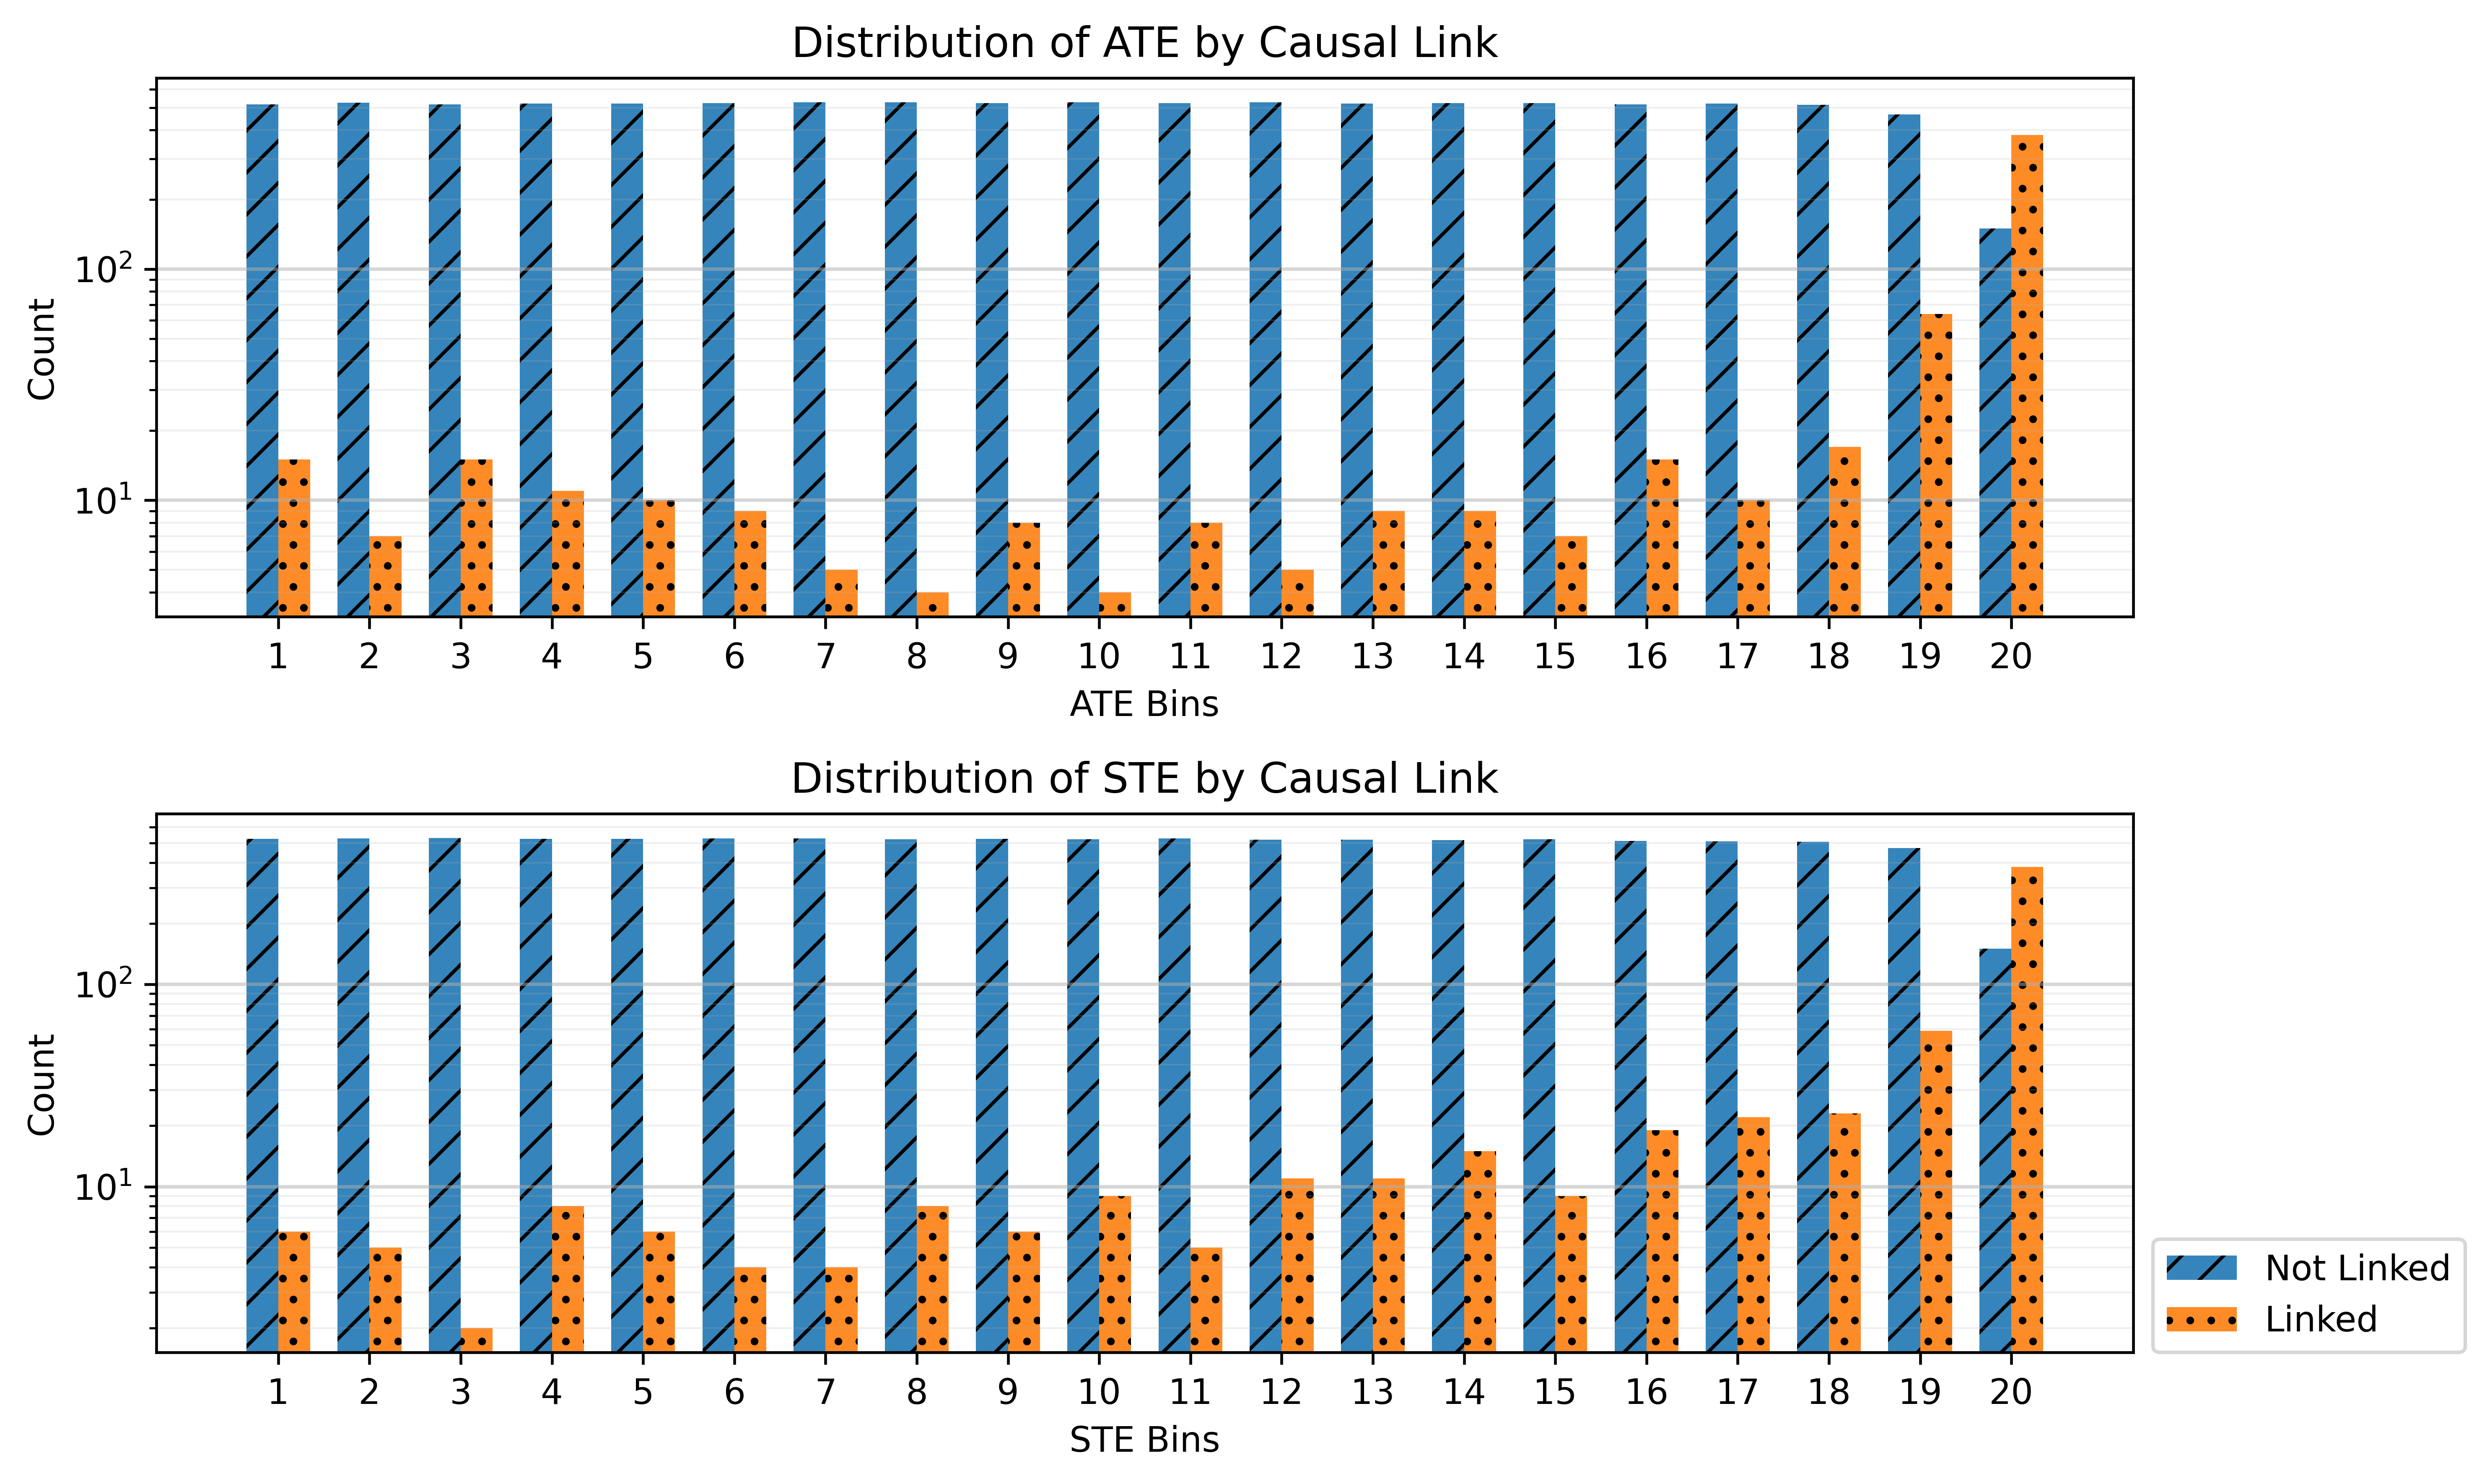

In [9]:
num_bins = 20
w = 0.35
hatches = ["//", ".."]

fig, axes = plt.subplots(2, 1, figsize=(10, 6), dpi=600)

for ax, metric in zip(axes, ["ATE", "STE"]):

    # Quantile bins for the current metric
    bins = np.quantile(
        raw_results[metric].values,
        np.arange(0, 1, 1 / num_bins)
    )

    df = raw_results[[metric, 'causal_link']].copy()
    df['metric_bin'] = np.digitize(df[metric], bins) - 1

    for link in [0, 1]:
        subset = df[df['causal_link'] == link]
        counts = subset['metric_bin'].value_counts().sort_index()

        ax.bar(
            counts.index + (link - 0.5) * w,
            counts.values,
            width=w,
            alpha=0.9,
            hatch=hatches[link],
            label='Linked' if link == 1 else 'Not Linked'
        )

    ax.set_xticks(range(num_bins))
    ax.set_xticklabels(range(1, num_bins + 1))
    ax.set_xlabel(f'{metric} Bins')
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of {metric} by Causal Link')

    ax.set_yscale('log')
    ax.grid(axis='y', which='major', alpha=0.5, linewidth=1)
    ax.grid(axis='y', which='minor', alpha=0.2, linewidth=0.5)

plt.legend(loc=(1.01, 0))
plt.tight_layout()
plt.savefig(
    base_artifacts / 'Figures' / 'simulation' / 'distribution_bins_synthetic.jpeg', 
    bbox_inches='tight'
)
plt.show()


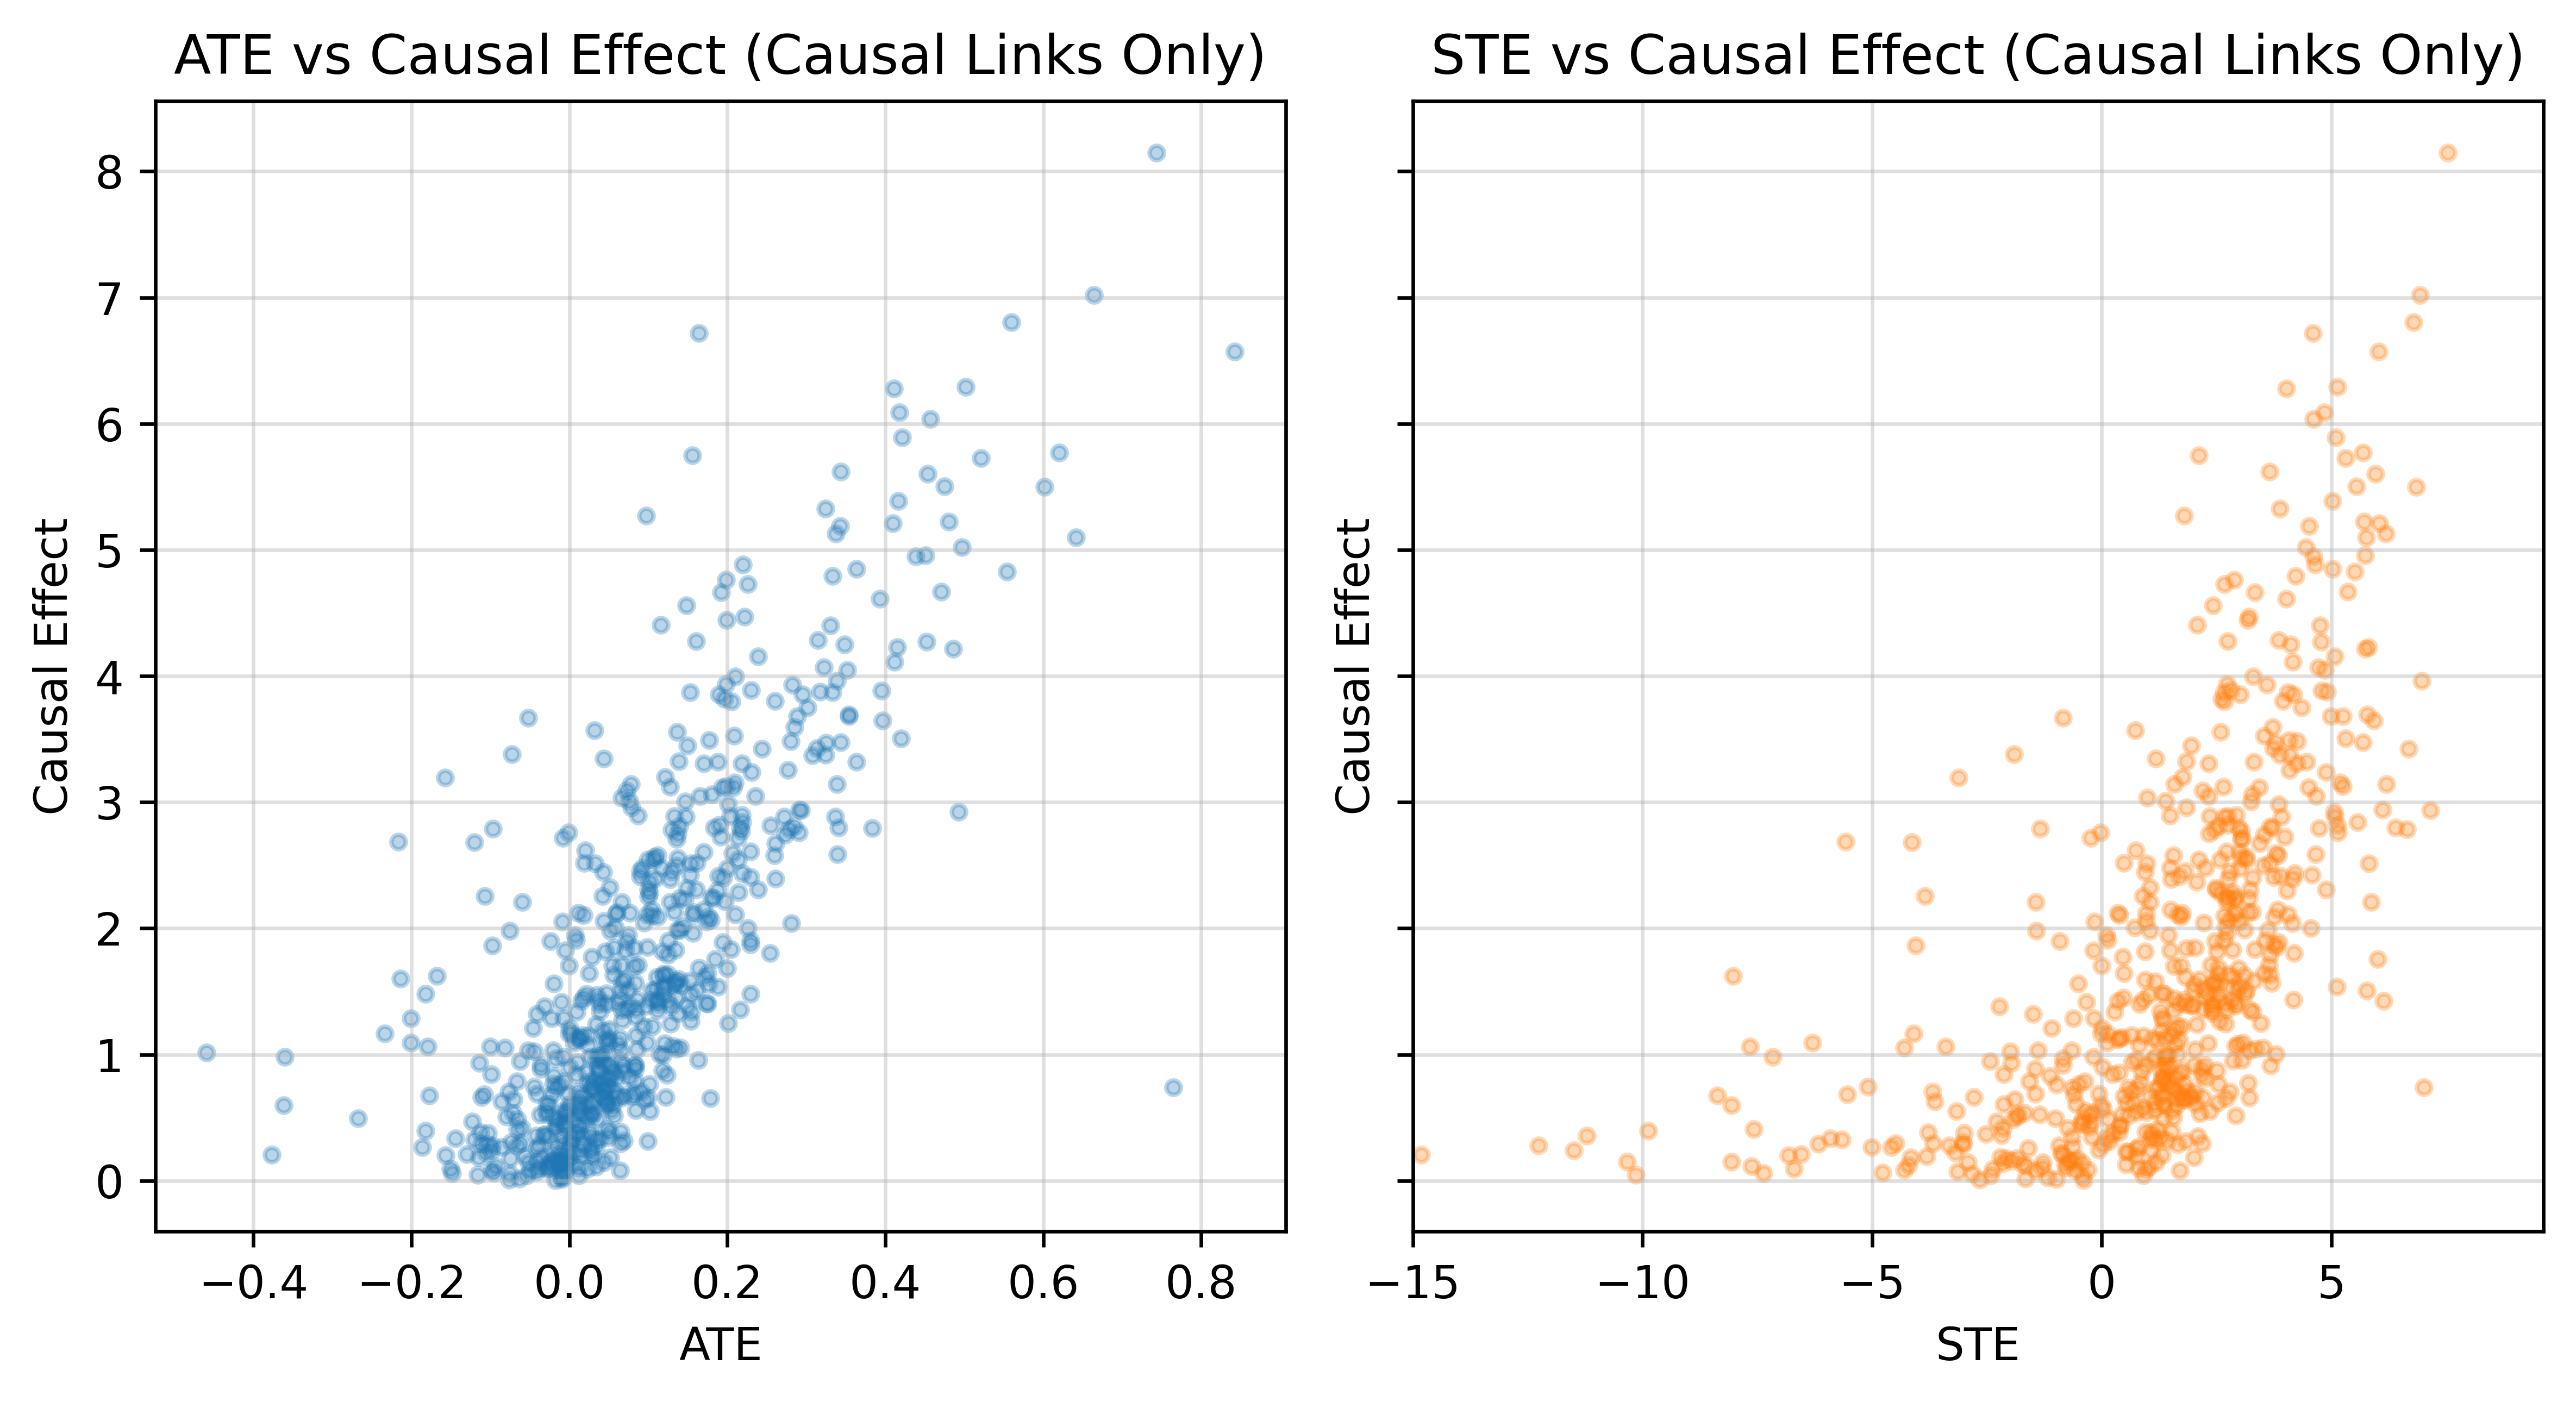

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4.5), dpi=600, sharey=True)

subset = raw_results[raw_results['causal_link'] == 1]
cols = ['ATE', 'STE']
colors = ['tab:blue', 'tab:orange']

for j in range(2):
    axes[j].scatter(
        subset[cols[j]],
        subset['causal_effect'],
        color=colors[j],
        alpha=0.3,
        s=10
    )
    axes[j].set_xlabel(cols[j])
    axes[j].set_ylabel('Causal Effect')
    axes[j].set_title(f'{cols[j]} vs Causal Effect (Causal Links Only)')
    axes[j].grid(alpha=0.4)
    axes[j].set_box_aspect(1)

axes[1].set_xlim(-15)
plt.tight_layout()
plt.savefig(
    base_artifacts / 'Figures' / 'simulation' / 'scatter_ate_vs_ste_causal_effect_(linked_only).jpeg',
    bbox_inches='tight'
)
plt.show()
